Assignment 5

Name: Shantanu Kaute | Roll No. 07 | PRN no. 1252090007

5.Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks: 1. Pre-process the dataset. 2. Identify outliers. 3. Check the correlation. 4. Implement linear regression and ridge, Lasso regression models. 5. Evaluate the models and compare their respective scores like R2, RMSE, etc. Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset



1: Import Libraries & Load Dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error


In [32]:
df = pd.read_csv("uber.csv", on_bad_lines='skip', low_memory=False)
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.73835372924805,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.74077,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


2: Dataset Information

In [33]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373202 entries, 0 to 373201
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         373202 non-null  object 
 1   key                373202 non-null  object 
 2   fare_amount        373201 non-null  object 
 3   pickup_datetime    373201 non-null  object 
 4   pickup_longitude   373200 non-null  float64
 5   pickup_latitude    373197 non-null  object 
 6   dropoff_longitude  373190 non-null  float64
 7   dropoff_latitude   373187 non-null  float64
 8   passenger_count    373183 non-null  float64
dtypes: float64(4), object(5)
memory usage: 25.6+ MB
None
       pickup_longitude  dropoff_longitude  dropoff_latitude  passenger_count
count     373200.000000      373190.000000     373187.000000    373183.000000
mean         -72.522606         -72.521704         39.922064         1.685246
std           11.472217          13.304014          6.84583

3: Data Pre-Processing

Remove missing values

In [34]:
df = df.dropna().copy()
# Convert potentially problematic columns to numeric
numeric_cols = ['fare_amount', 'pickup_longitude', 'pickup_latitude',
                'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Drop rows where any of these critical numeric columns are NaN after conversion
df = df.dropna(subset=numeric_cols)

Convert date-time (if present)

In [35]:
if 'pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])


Remove unnecessary columns

In [36]:
df = df.drop(columns=['key'], errors='ignore')


4: Outlier Detection (Box Plot)

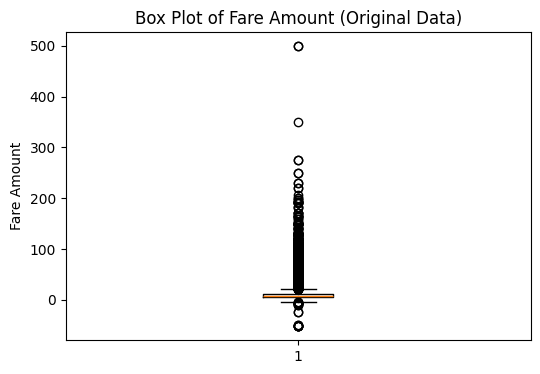

In [37]:
plt.figure(figsize=(6,4))
plt.boxplot(df['fare_amount'])
plt.title("Box Plot of Fare Amount (Original Data)")
plt.ylabel("Fare Amount")
plt.show()


Remove outliers (Fare ≤ 0)

In [38]:
df = df[df['fare_amount'] > 0]


5: Correlation Analysis

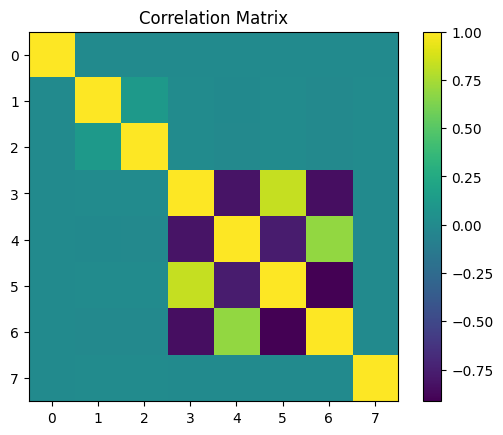

In [39]:
corr = df.corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()


6: Feature Selection

Input Features (X) and Target (y)

In [40]:
X = df[['pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude',
        'passenger_count']]

y = df['fare_amount']


7: Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


8: Linear Regression Model

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


Evaluation

In [43]:
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R2:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)


Linear Regression R2: -3.1224939597063184e-05
Linear Regression RMSE: 9.817549032881674


9: Ridge Regression Model

In [44]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)


Evaluation

In [45]:
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression R2:", r2_ridge)
print("Ridge Regression RMSE:", rmse_ridge)


Ridge Regression R2: -3.122464174332151e-05
Ridge Regression RMSE: 9.817549031419622


10: Lasso Regression Model

In [46]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)


Evaluation

In [47]:
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression R2:", r2_lasso)
print("Lasso Regression RMSE:", rmse_lasso)


Lasso Regression R2: -1.7230540784618498e-05
Lasso Regression RMSE: 9.817480339438028


11: Model Comparison

In [48]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2 Score': [r2_lr, r2_ridge, r2_lasso],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso]
})

results


,Model,R2 Score,RMSE
0,Linear Regression,-0.000031,9.817549
1,Ridge Regression,-0.000031,9.817549
2,Lasso Regression,-0.000017,9.817480


Conclusion:

- Linear Regression gives baseline prediction.

- Ridge Regression reduces overfitting using regularization.

- Lasso Regression performs feature selection.

- Model with highest R² and lowest RMSE performs best.